In [49]:
import yaml
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [50]:
CONFIG_DIR = Path("configs")


In [51]:
# usefull for converting back to raw
data_raw = pd.read_csv(
    'data/MSFT/MSFT_1d.csv',
    # index_col='Date',
    parse_dates=True
)


# Naive

In [52]:
NAIVE_CONFIG_PATH = CONFIG_DIR / "naive"


In [53]:
diff_mape = []
no_diff_mape = []
diff_conf = []
raw_conf = []
for file_path in os.listdir(NAIVE_CONFIG_PATH):
    with open(NAIVE_CONFIG_PATH/file_path, 'r' ) as file:
        conf = yaml.safe_load(file)

    if conf['diff']:
        # diff_mape.append(conf['metrics']['mape'])
        diff_conf.append((conf["results_file_path"], conf['horizon']))
    else:
        # no_diff_mape.append(conf['metrics']['mape'])
        raw_conf.append((conf["results_file_path"], conf['horizon']))

### No diff

In [54]:
raw_mape = []

for test_dat, test_hor in raw_conf:
    
    df = pd.read_csv(test_dat, parse_dates=True)
    
    mape = mean_absolute_percentage_error(df["Actual"], df["naive"]) * 100

    print("MAPE:",mape)
    raw_mape.append(mape)

MAPE: 7.207376361821065
MAPE: 1.2183760536503425
MAPE: 3.198621398840061
MAPE: 2.056026825231449


### Diff

In [55]:
diff_mape = []
for test_dat, test_hor in diff_conf:
    
    df = pd.read_csv(test_dat, parse_dates=True)
    
    mape = mean_absolute_percentage_error(df["Actual"], df["naive"]) * 100

    print("MAPE:",mape)
    diff_mape.append(mape)

MAPE: 272.42900630678827
MAPE: 273.44414759172787
MAPE: 399.206760780935
MAPE: 292.1496774732421


### Converted to real values

In [56]:
converted_mape = []
for test_dat, test_hor in diff_conf:

    df = pd.read_csv(test_dat, parse_dates=True)
    
    test_start = data_raw.index[(data_raw['Date'] < df.iloc[0]["Date"])].max()
    
    reversed_diff_actual = df["Actual"].cumsum() + data_raw.iloc[test_start]["Open"] 
    reversed_diff_naive = df["naive"].cumsum() + data_raw.iloc[test_start]["Open"] 
    
    mape = mean_absolute_percentage_error(reversed_diff_actual, reversed_diff_naive) * 100

    print("MAPE:",mape)
    converted_mape.append(mape)

MAPE: 34.9926828814375
MAPE: 31.210089466927148
MAPE: 64.22779463016846
MAPE: 1.339130769056912


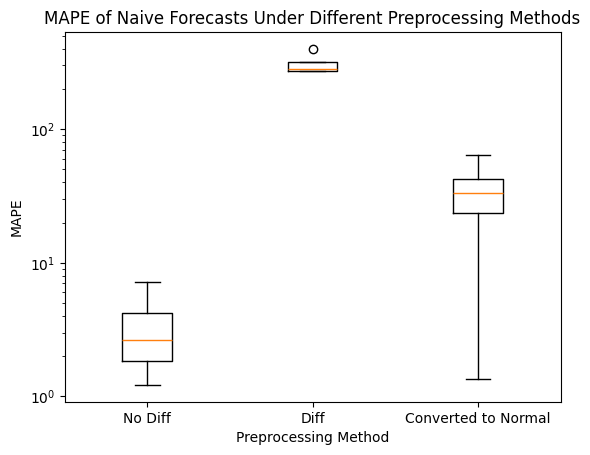

In [57]:
data_to_plot = [raw_mape, diff_mape, converted_mape]
labels = ["No Diff", "Diff", "Converted to Normal"]
plt.boxplot(data_to_plot,label=labels)

plt.xticks([1, 2, 3], ["No Diff", "Diff", "Converted to Normal"])
plt.yscale('log')
plt.title('MAPE of Naive Forecasts Under Different Preprocessing Methods')
plt.ylabel('MAPE')
plt.xlabel('Preprocessing Method')
plt.show()

# ARIMA

In [58]:
ARIMA_CONFIG_DIR = CONFIG_DIR / "arima"


In [59]:
# diff_mape = []
# no_diff_mape = []
diff_conf = []
raw_conf = []
for file_path in os.listdir(ARIMA_CONFIG_DIR):
    
    with open(ARIMA_CONFIG_DIR/file_path, 'r' ) as file:
        conf = yaml.load(file, Loader= yaml.FullLoader)

    if conf['diff']:
        # diff_mape.append(conf['metrics']['mape'])
        diff_conf.append((conf["results_file_path"], conf['horizon']))
    else:
        # no_diff_mape.append(conf['metrics']['mape'])
        raw_conf.append((conf["results_file_path"], conf['horizon']))

In [60]:
len(raw_conf), len(diff_conf)

(24, 24)

### No diff

In [61]:
raw_mape = []

for test_dat, test_hor in raw_conf:
    
    df = pd.read_csv(test_dat, parse_dates=True)
    
    mape = mean_absolute_percentage_error(df["Actual"], df["arima"]) * 100

    print("MAPE:",mape)
    raw_mape.append(mape)

MAPE: 3.198621398840061
MAPE: 1.2131460094339697
MAPE: 3.1558334191528536
MAPE: 1.209706189463147
MAPE: 2.056026825231449
MAPE: 1.2100841372810696
MAPE: 3.288116359949924
MAPE: 2.032455479733859
MAPE: 3.1819259142528042
MAPE: 1.2090857755430389
MAPE: 6.865807652227295
MAPE: 2.0566459333617018
MAPE: 6.702327183751754
MAPE: 1.2183760536503425
MAPE: 1.2183760536503425
MAPE: 7.207376361821065
MAPE: 3.17187039629614
MAPE: 2.056026825231449
MAPE: 2.022688213892865
MAPE: 2.0292458694857607
MAPE: 7.207376361821065
MAPE: 7.310890527834149
MAPE: 6.789653634772799
MAPE: 3.198621398840061


### Diff

In [62]:
diff_mape = []
for test_dat, test_hor in diff_conf:
    
    df = pd.read_csv(test_dat, parse_dates=True)
    
    mape = mean_absolute_percentage_error(df["Actual"], df["arima"]) * 100

    print("MAPE:",mape)
    diff_mape.append(mape)

MAPE: 100.0
MAPE: 100.0
MAPE: 100.0
MAPE: 100.0
MAPE: 102.14117672434091
MAPE: 102.16609988246978
MAPE: 100.07311911125858
MAPE: 105.9297787831808
MAPE: 101.45277152869691
MAPE: 100.54265784083738
MAPE: 105.43940259665891
MAPE: 100.0
MAPE: 105.0661544181958
MAPE: 100.5432601965933
MAPE: 101.4473859766152
MAPE: 103.17083025057845
MAPE: 100.0
MAPE: 105.22302663933986
MAPE: 100.0
MAPE: 100.0
MAPE: 100.77536223663412
MAPE: 102.55970242464775
MAPE: 101.68120650407523
MAPE: 100.79388189201543


### Converted to real values

In [63]:
converted_mape = []
for test_dat, test_hor in diff_conf:

    df = pd.read_csv(test_dat, parse_dates=True)
    
    test_start = data_raw.index[(data_raw['Date'] < df.iloc[0]["Date"])].max()
    
    reversed_diff_actual = df["Actual"].cumsum() + data_raw.iloc[test_start]["Open"] 
    reversed_diff_naive = df["arima"].cumsum() + data_raw.iloc[test_start]["Open"] 
    
    mape = mean_absolute_percentage_error(reversed_diff_actual, reversed_diff_naive) * 100

    print("MAPE:",mape)
    converted_mape.append(mape)

MAPE: 23.24134683117843
MAPE: 23.24134683117843
MAPE: 23.24134683117843
MAPE: 23.24134683117843
MAPE: 18.541433167122474
MAPE: 21.142116182714705
MAPE: 23.4449957577048
MAPE: 27.226294803927253
MAPE: 20.12917317565655
MAPE: 19.78339507520688
MAPE: 21.274495408121734
MAPE: 23.24134683117843
MAPE: 23.103869377475164
MAPE: 25.072908128144363
MAPE: 18.26067379603661
MAPE: 19.473956212227808
MAPE: 23.24134683117843
MAPE: 22.40934056045922
MAPE: 23.24134683117843
MAPE: 23.24134683117843
MAPE: 23.924997723209863
MAPE: 20.554406398441927
MAPE: 19.543409087088488
MAPE: 19.21428555731555


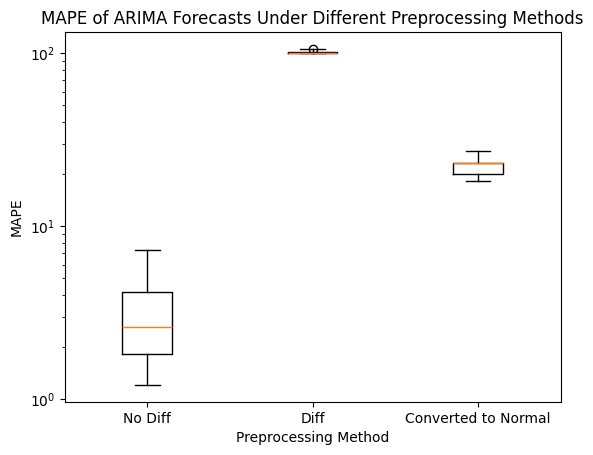

In [64]:
data_to_plot = [raw_mape, diff_mape, converted_mape]
labels = ["No Diff", "Diff", "Converted to Normal"]
plt.boxplot(data_to_plot,label=labels)

plt.xticks([1, 2, 3], ["No Diff", "Diff", "Converted to Normal"])
plt.yscale('log')
plt.title('MAPE of ARIMA Forecasts Under Different Preprocessing Methods')
plt.ylabel('MAPE')
plt.xlabel('Preprocessing Method')
plt.show()

### TimesFM

In [65]:
TIMES_CONFIG_PATH = CONFIG_DIR / "fm"


In [66]:
diff_mape = []
no_diff_mape = []
diff_conf = []
raw_conf = []
for file_path in os.listdir(TIMES_CONFIG_PATH):
    with open(TIMES_CONFIG_PATH/file_path, 'r' ) as file:
        conf = yaml.safe_load(file)

    if conf['diff']:
        # diff_mape.append(conf['metrics']['mape'])
        diff_conf.append((conf["results_file_path"], conf['horizon']))
    else:
        # no_diff_mape.append(conf['metrics']['mape'])
        raw_conf.append((conf["results_file_path"], conf['horizon']))

### No diff

In [67]:
raw_mape = []

for test_dat, test_hor in raw_conf:
    
    df = pd.read_csv(test_dat, parse_dates=True)
    
    mape = mean_absolute_percentage_error(df["Actual"], df["fm"]) * 100

    print("MAPE:",mape)
    raw_mape.append(mape)

MAPE: 0.6691767485181873
MAPE: 1.3454690018936561
MAPE: 8.156381984106616
MAPE: 0.3085762410296964
MAPE: 8.464650833121489
MAPE: 3.9479081556817937
MAPE: 0.526429458602718
MAPE: 0.38902535960445145
MAPE: 7.9585883428473805
MAPE: 4.109100620751187
MAPE: 1.5176527543688594
MAPE: 3.8710345798151518
MAPE: 7.9843686344217915
MAPE: 0.5825700720415127
MAPE: 3.926194151162749
MAPE: 3.9329468959612304
MAPE: 1.4449396045538918
MAPE: 7.6916261084866235
MAPE: 1.6044176122514793
MAPE: 1.3681223875798663
MAPE: 7.9843686344217915
MAPE: 0.5259826468348751
MAPE: 1.8837273300569082
MAPE: 3.9405368889227153


### Diff

In [68]:
diff_mape = []
for test_dat, test_hor in diff_conf:
    
    df = pd.read_csv(test_dat, parse_dates=True)
    
    mape = mean_absolute_percentage_error(df["Actual"], df["fm"]) * 100

    print("MAPE:",mape)
    diff_mape.append(mape)

MAPE: 105.9177950045719
MAPE: 105.27574144451715
MAPE: 109.51632219519205
MAPE: 104.66727233007214
MAPE: 105.09134559160151
MAPE: 104.45522295223913
MAPE: 107.96935539651238
MAPE: 105.11965035137314
MAPE: 103.53371785390351
MAPE: 111.87949676042659
MAPE: 102.2834308906584
MAPE: 104.49394791504471
MAPE: 112.19934134711802
MAPE: 106.20623994433855
MAPE: 114.93246416081944
MAPE: 109.51205689771587
MAPE: 114.87376385860053
MAPE: 100.86174390740497
MAPE: 105.78433111446049
MAPE: 113.63664083785253
MAPE: 102.27631418616387
MAPE: 106.5239897857034
MAPE: 105.27574144451715
MAPE: 105.86307058146913


### Converted to real values

In [69]:
converted_mape = []
for test_dat, test_hor in diff_conf:

    df = pd.read_csv(test_dat, parse_dates=True)
    
    test_start = data_raw.index[(data_raw['Date'] < df.iloc[0]["Date"])].max()
    
    reversed_diff_actual = df["Actual"].cumsum() + data_raw.iloc[test_start]["Open"] 
    reversed_diff_naive = df["fm"].cumsum() + data_raw.iloc[test_start]["Open"] 
    
    mape = mean_absolute_percentage_error(reversed_diff_actual, reversed_diff_naive) * 100

    print("MAPE:",mape)
    converted_mape.append(mape)

MAPE: 23.748837288942013
MAPE: 14.424532452530428
MAPE: 14.367753820520567
MAPE: 14.060719871015252
MAPE: 14.09064710374062
MAPE: 18.07841959252516
MAPE: 10.978079573411872
MAPE: 13.81260203399895
MAPE: 27.168377949630557
MAPE: 12.31352015649191
MAPE: 15.625467075660232
MAPE: 10.49111676110325
MAPE: 21.722599076566514
MAPE: 19.93040925141617
MAPE: 14.146305960647565
MAPE: 14.33867179719741
MAPE: 13.318749001859926
MAPE: 18.305225021837902
MAPE: 13.520373180506102
MAPE: 21.039164303250637
MAPE: 26.436932224270105
MAPE: 13.209490080463418
MAPE: 14.424532452530428
MAPE: 23.98778912118394


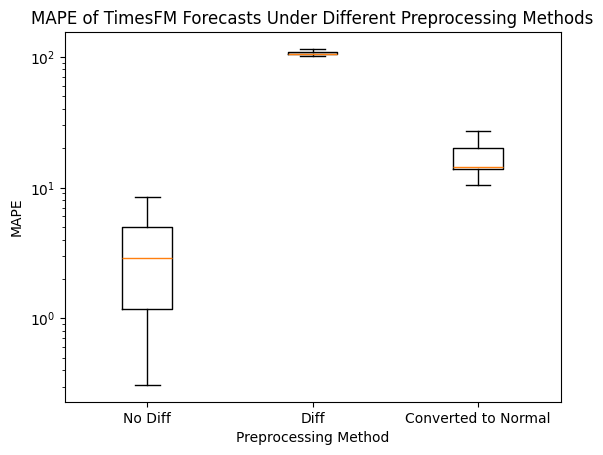

In [70]:
data_to_plot = [raw_mape, diff_mape, converted_mape]
labels = ["No Diff", "Diff", "Converted to Normal"]
plt.boxplot(data_to_plot,label=labels)

plt.xticks([1, 2, 3], ["No Diff", "Diff", "Converted to Normal"])
plt.yscale('log')
plt.title('MAPE of TimesFM Forecasts Under Different Preprocessing Methods')
plt.ylabel('MAPE')
plt.xlabel('Preprocessing Method')
plt.show()

In [71]:
def get_box_plots(method: str = "naive", plot:bool=False):
    METHOD_CONFIG_DIR = CONFIG_DIR / method

    # diff_mape = []
    # no_diff_mape = []
    diff_conf = []
    raw_conf = []
    for file_path in os.listdir(METHOD_CONFIG_DIR):
        
        with open(METHOD_CONFIG_DIR/file_path, 'r' ) as file:
            conf = yaml.load(file, Loader= yaml.FullLoader)

        if conf['diff']:
            # diff_mape.append(conf['metrics']['mape'])
            diff_conf.append((conf["results_file_path"], conf['horizon']))
        else:
            # no_diff_mape.append(conf['metrics']['mape'])
            raw_conf.append((conf["results_file_path"], conf['horizon']))
    raw_mape = []

    for test_dat, test_hor in raw_conf:
        
        df = pd.read_csv(test_dat, parse_dates=True)
        
        mape = mean_absolute_percentage_error(df["Actual"], df[f"{method}"]) * 100

        # print("MAPE:",mape)
        raw_mape.append(mape)
    diff_mape = []
    for test_dat, test_hor in diff_conf:
        
        df = pd.read_csv(test_dat, parse_dates=True)
        
        mape = mean_absolute_percentage_error(df["Actual"], df[f"{method}"]) * 100

        # print("MAPE:",mape)
        diff_mape.append(mape)
    converted_mape = []
    for test_dat, test_hor in diff_conf:

        df = pd.read_csv(test_dat, parse_dates=True)
        
        test_start = data_raw.index[(data_raw['Date'] < df.iloc[0]["Date"])].max()
        
        reversed_diff_actual = df["Actual"].cumsum() + data_raw.iloc[test_start]["Open"] 
        reversed_diff_naive = df[f"{method}"].cumsum() + data_raw.iloc[test_start]["Open"] 
        
        mape = mean_absolute_percentage_error(reversed_diff_actual, reversed_diff_naive) * 100

        # print("MAPE:",mape)
        converted_mape.append(mape)
    if plot:
        data_to_plot = [raw_mape, diff_mape, converted_mape]
        labels = ["No Diff", "Diff", "Converted to Normal"]
        plt.boxplot(data_to_plot,label=labels)

        plt.xticks([1, 2, 3], ["No Diff", "Diff", "Converted to Normal"])
        plt.yscale('log')
        if method == 'fm':
            plt.title(f'MAPE of TimesFM Forecasts Under Different Preprocessing Methods')
        else:
            plt.title(f'MAPE of {method.upper()} Forecasts Under Different Preprocessing Methods')
        plt.ylabel('MAPE')
        plt.xlabel('Preprocessing Method')
        plt.show()
    else:
        return (raw_mape, diff_mape, converted_mape)

In [72]:
arima_raw_mape, arima_diff_mape, arima_converted_mape = get_box_plots(method="arima")
naive_raw_mape, naive_diff_mape, naive_converted_mape = get_box_plots(method="naive")
fm_raw_mape, fm_diff_mape, fm_converted_mape = get_box_plots(method="fm")

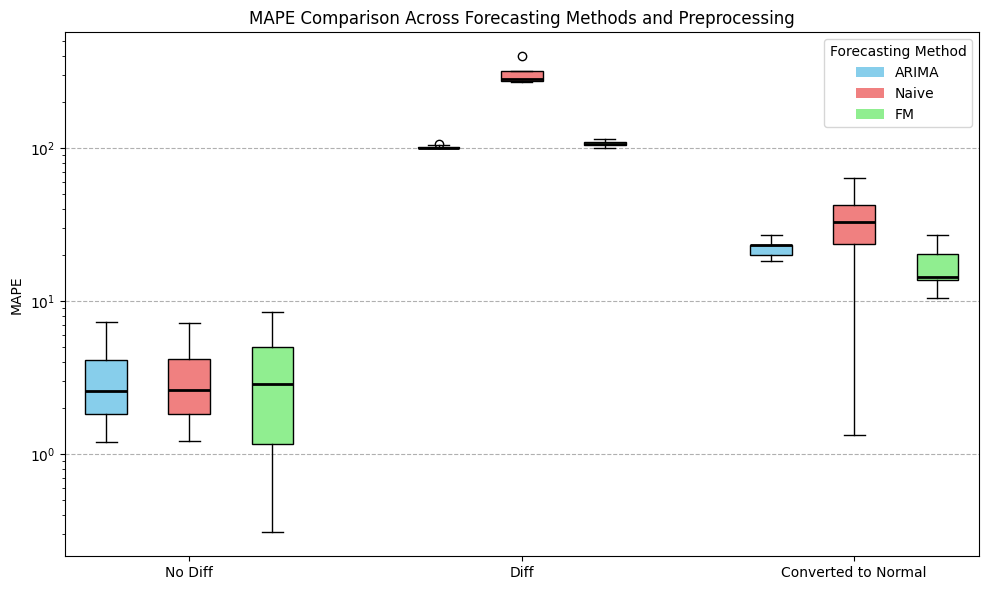

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming get_box_plots returns lists of MAPE values
# def get_box_plots(method):
#     if method == "arima":
#         return np.random.uniform(10, 50, 20), np.random.uniform(5, 20, 20), np.random.uniform(15, 60, 20)
#     elif method == "naive":
#         return np.random.uniform(5, 25, 20), np.random.uniform(2, 10, 20), np.random.uniform(8, 30, 20)
#     elif method == "fm":
#         return np.random.uniform(12, 40, 20), np.random.uniform(7, 22, 20), np.random.uniform(18, 55, 20)
#     else:
#         return [], [], []

arima_raw_mape, arima_diff_mape, arima_converted_mape = get_box_plots(method="arima")
naive_raw_mape, naive_diff_mape, naive_converted_mape = get_box_plots(method="naive")
fm_raw_mape, fm_diff_mape, fm_converted_mape = get_box_plots(method="fm")

# Prepare the data for the box plot
data = [arima_raw_mape, naive_raw_mape, fm_raw_mape,
        arima_diff_mape, naive_diff_mape, fm_diff_mape,
        arima_converted_mape, naive_converted_mape, fm_converted_mape]

# Define the labels for each box plot (for the x-axis)
labels = ['ARIMA', 'Naive', 'FM',
          'ARIMA', 'Naive', 'FM',
          'ARIMA', 'Naive', 'FM']

# Define the x-axis positions for the boxes
x_positions = [1, 2, 3, 5, 6, 7, 9, 10, 11]

# Define colors for each method
colors = {'ARIMA': 'skyblue', 'Naive': 'lightcoral', 'FM': 'lightgreen'}
method_labels = ['ARIMA', 'Naive', 'FM']
box_colors = [colors[label] for label in ['ARIMA', 'Naive', 'FM'] * 3]

# Define the color and linewidth for the median line
median_color = 'black'  # You can choose any contrasting color
median_linewidth = 2    # Adjust as needed for visibility

# Create the box plot
plt.figure(figsize=(10, 6))
boxes = plt.boxplot(data, positions=x_positions, tick_labels=labels, patch_artist=True,
                    medianprops={'color': median_color, 'linewidth': median_linewidth})

# Color the boxes
for patch, color in zip(boxes['boxes'], box_colors):
    patch.set_facecolor(color)

# Create a legend for the box colors
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[method]) for method in method_labels]
plt.legend(handles, method_labels, title='Forecasting Method')

# Customize the plot
plt.title('MAPE Comparison Across Forecasting Methods and Preprocessing')
plt.ylabel('MAPE')
plt.xticks([2, 6, 10], ['No Diff', 'Diff', 'Converted to Normal']) # Set x-axis labels for the groups
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.yscale('log')
plt.show()